# Лабораторна робота №7
**Тема:** Дослідження та візуалізація даних за допомогою Pandas  <br>
**Мета:** отримати базові навики використання Pandas для дослідження та візуалізації даних.

In [69]:
print(f"Варіант №{ord("Derypasko"[0]) % 3 + 1}")

Варіант №3


## Завдання:
1. Знайдіть добові втрати БТР.
2. Знайдіть 5 найбільших добових втрат БТР і визначте дати.
3. Визначте, скільки БТР було знищено влітку 2024 року.
4. Знайдіть середнє значення знищених БТР за 100-500 днів війни.
5. Створіть графік втрат БТР та особового складу за останні 200 днів (починаючи з останньої дати в наборі даних)

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
df = pd.read_csv("russia_losses_equipment.csv")
df.head()

,date,day,aircraft,helicopter,tank,APC,field artillery,MRL,military auto,fuel tank,drone,naval ship,anti-aircraft warfare,special equipment,mobile SRBM system,greatest losses direction,vehicles and fuel tanks,cruise missiles,submarines
0,2025-11-09,1355,428,347,11335,23545,34340,1538,NaN,NaN,79368,28,1239,3993.0,NaN,NaN,66880.0,3926.0,1.0
1,2025-11-08,1354,428,347,11330,23544,34321,1538,NaN,NaN,78928,28,1239,3993.0,NaN,NaN,66795.0,3918.0,1.0
2,2025-11-07,1353,428,346,11330,23543,34301,1535,NaN,NaN,78678,28,1238,3993.0,NaN,NaN,66723.0,3918.0,1.0
3,2025-11-06,1352,428,346,11329,23541,34288,1535,NaN,NaN,78430,28,1237,3991.0,NaN,NaN,66658.0,3918.0,1.0
4,2025-11-05,1351,428,346,11329,23535,34273,1535,NaN,NaN,78258,28,1237,3990.0,NaN,NaN,66574.0,3918.0,1.0


## Завдання №1: Знайти добові втрати БТР

In [72]:
daily = df[["date","APC"]].copy()
daily = daily.iloc[::-1]
daily["APC"] = daily["APC"].diff().fillna(daily['APC'])
daily = daily.iloc[::-1]
daily

,date,APC
0,2025-11-09,1.0
1,2025-11-08,1.0
2,2025-11-07,2.0
3,2025-11-06,6.0
4,2025-11-05,3.0
...,...,...
1349,2022-03-01,30.0
1350,2022-02-28,110.0
1351,2022-02-27,0.0
1352,2022-02-26,190.0


## Завдання №2: Знайдіть 5 найбільших добових втрат БТР і визначте дати.

In [73]:
daily = df[["date","APC"]].copy()
daily = daily.iloc[::-1]
daily["APC"] = daily["APC"].diff().fillna(daily['APC'])
daily = daily.iloc[::-1]
daily = daily.sort_values("APC", ascending=False)
daily.head()

,date,APC
1353,2022-02-25,516.0
1352,2022-02-26,190.0
751,2023-10-20,120.0
1350,2022-02-28,110.0
1334,2022-03-16,96.0


## Завдання №3: Визначте, скільки БТР було знищено влітку 2024 року.

In [74]:
print((df[df["date"] == "2024-08-31"]["APC"].values - df[df["date"] == "2024-06-01"]["APC"].values)[0])

1789


## Завдання №4: Знайдіть середнє значення знищених БТР за 100-500 днів війни.

In [75]:
avg = df.copy()[::-1]
print(avg.iloc[100:500:]["APC"].mean())

5817.675


## Завдання №5: Створіть графік втрат БТР та особового складу за останні 200 днів (починаючи з останньої дати в наборі даних)

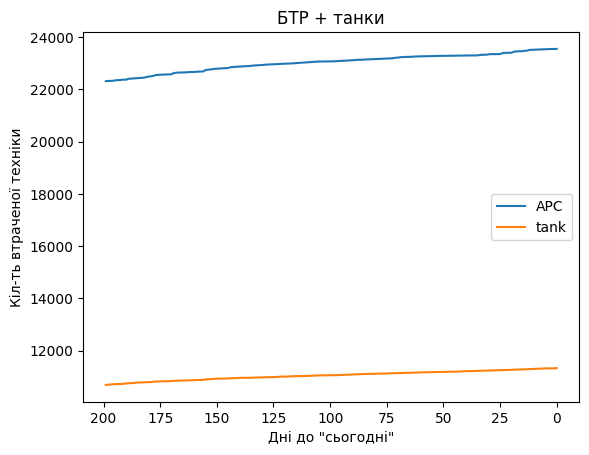

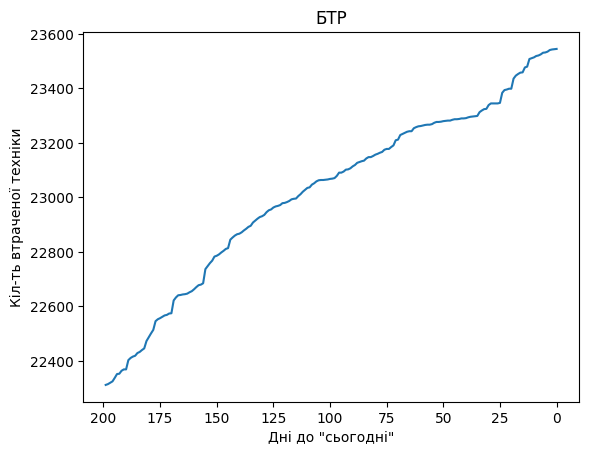

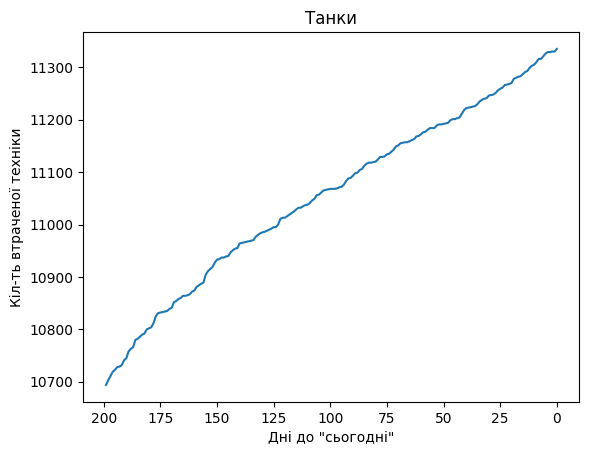

In [76]:
APC_tank = df.iloc[:200][["APC", "tank"]]
APC_tank.plot()
plt.xlabel("Дні до \"сьогодні\"")
plt.ylabel("Кіл-ть втраченої техніки")
plt.title("БТР + танки")
plt.gca().invert_xaxis()
plt.show()

APC = df.iloc[:200]["APC"]
APC.plot()
plt.xlabel("Дні до \"сьогодні\"")
plt.ylabel("Кіл-ть втраченої техніки")
plt.title("БТР")
plt.gca().invert_xaxis()
plt.show()

tank = df.iloc[:200]["tank"]
tank.plot()
plt.xlabel("Дні до \"сьогодні\"")
plt.ylabel("Кіл-ть втраченої техніки")
plt.title("Танки")
plt.gca().invert_xaxis()
plt.show()